Max price is 116.8
Min price is 9.33
Mean price is 57.88402292950034
Max load is 41015.0
Min load is 18041.0
Mean load is 28696.93990521868


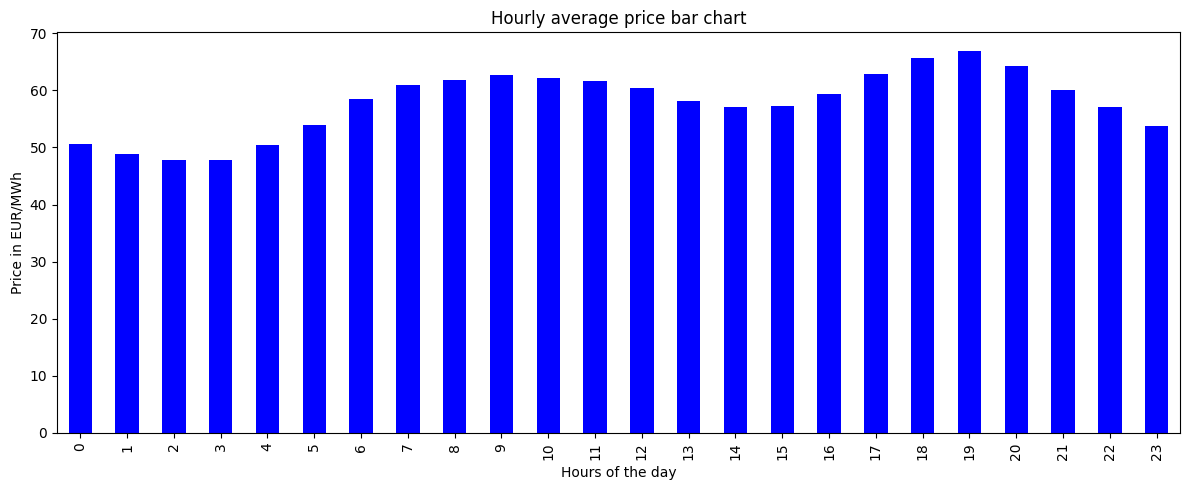

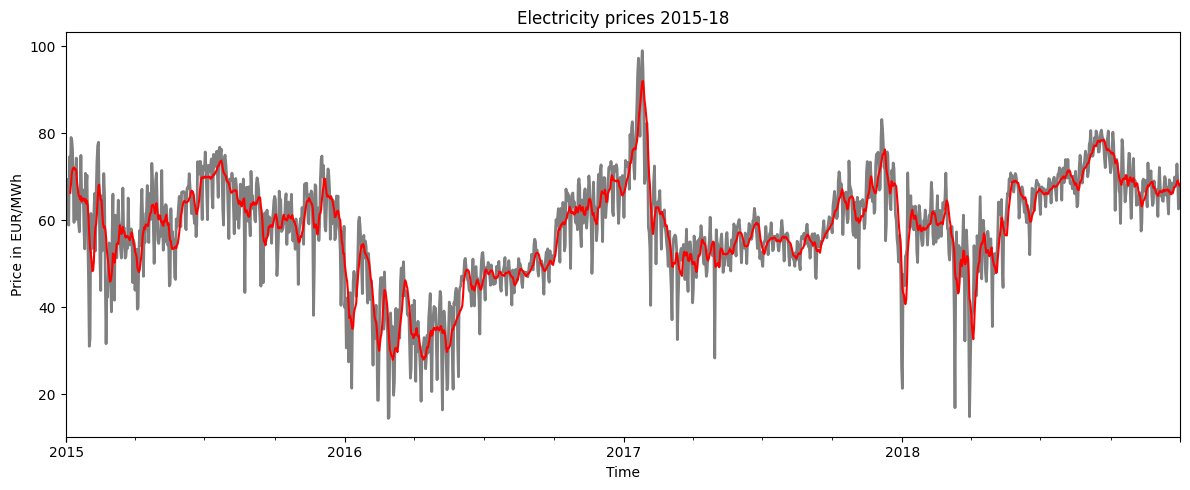

Correlation between Price and total load is 0.43612722035325413
Correlation between Price and generation fossil gas is 0.46170557449815497
The slopes of our 2 variables are: [[0.00081302 0.00201999]]
The intercept is: [23.20179075]
MAE:9.48 EUR/MWh


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("energy_dataset.csv") # Load and clean data
df["time"] = pd.to_datetime(df["time"] , utc =True) # Converting rows to usable time
df["hour"] = df["time"].dt.hour # converting each row as an hour
df = df.set_index("time") 
max_price = df["price actual"].max() #  max function used to calculate maximum value in the dataset
min_price = df["price actual"].min() #  min function used to calculate minimum value in the dataset
mean_price = df["price actual"].mean() #  mean function used to calculate average value in the dataset
max_load = df["total load actual"].max()
min_load = df["total load actual"].min()
mean_load = df["total load actual"].mean()
print(f"Max price is {max_price}")
print(f"Min price is {min_price}")
print(f"Mean price is {mean_price}")
print(f"Max load is {max_load}")
print(f"Min load is {min_load}")
print(f"Mean load is {mean_load}")
hourly_avg = df.groupby("hour")["price actual"].mean() # Grouping all values by day of hour like all 1 am of every day is together and mean function given average value for that hour
daily_avg = df["price actual"].resample("D").mean() # resampling the data in groups of day and averaging values within the day
weekly_avg = daily_avg.rolling(window=7).mean() # rolling function rolls the data based on the window provided, this means that an average value of current value with the prior values within the winndow is given
hourly_avg.plot(kind="bar", figsize=(12,5), color="blue") # this is the generic code for how to make a plot of bar chart
plt.title("Hourly average price bar chart")
plt.xlabel("Hours of the day")
plt.ylabel("Price in EUR/MWh")
plt.tight_layout()
plt.show()
daily_avg.plot(kind="line", figsize=(12,5), color="grey", linewidth=2) # again generic code for line graphs
weekly_avg.plot(kind="line", figsize=(12,5), color="red")
plt.title("Electricity prices 2015-18")
plt.xlabel("Time")
plt.ylabel("Price in EUR/MWh")
plt.tight_layout()
plt.show()
corr1 = df["price actual"].corr(df["total load actual"]) # this correlates 2 columns in dataset, 1 is positive, -1 is negative and 0 is no relation
corr2 = df["price actual"].corr(df["generation fossil gas"])
print(f"Correlation between Price and total load is {corr1}")
print(f"Correlation between Price and generation fossil gas is {corr2}")
df2  = df[["price actual", "total load actual", "generation fossil gas"]].dropna() # drops rows with missing values of any of the mentioned columns
X = df2[["total load actual", "generation fossil gas"]].values # variable X 
y = df2[["price actual"]].values # variable y
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, random_state=42) # 20% of the data is testing site for the prediction model based from 80% of the data. helps understand efficiency of our prediction system
from sklearn.linear_model import LinearRegression # yeah this is just how to do the linear series based on y = mX+c
model = LinearRegression()
model.fit(X_train,y_train)
print(f"The slopes of our 2 variables are: {model.coef_}") # this is m, the slope
print(f"The intercept is: {model.intercept_}") # this is c, the intercept
from sklearn.metrics import mean_absolute_error 
y_pred = model.predict(X_test) # this is the prediction model code that used 80% data to predict the 20% values
mae = mean_absolute_error(y_test, y_pred) # this calculates the mean absolute error between the predicted model with the actual data in the 20% data
print(f"MAE:{mae:.2f} EUR/MWh")